# 🚗 Real-Time Accident Severity Prediction Model
**Goal:** Predict accident severity (1–4) using pre-accident features only  
**Model:** LightGBM with full ML pipeline (preprocessing → training → evaluation → export)

## 1. Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, cohen_kappa_score,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

import lightgbm as lgb
from lightgbm import LGBMClassifier

# Paths
DATA_PATH   = 'data.csv, index_col = 0'   # adjust to your path
ARTIFACT_DIR = '../artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

RANDOM_STATE = 42
print('Libraries loaded ✓')

Libraries loaded ✓


## 2. Load & Inspect Data

In [4]:
df = pd.read_csv('data.csv', index_col = 0)
print(f'Shape: {df.shape}')
df.head()

Shape: (152445, 16)


,ACCIDENT_NO,ACCIDENT_DATE,ACCIDENT_TIME,ACCIDENT_TYPE,ACCIDENT_TYPE_DESC,DAY_OF_WEEK,DAY_WEEK_DESC,DCA_CODE,DCA_DESC,LIGHT_CONDITION,NODE_ID,ROAD_GEOMETRY_DESC,SPEED_ZONE,RMA,HIGHWAY,SEVERITY
0,T20120000060,1/1/2012,19:40:00,6,Vehicle overturned (no collision),6,Sunday,184,OUT OF CONTROL ON CARRIAGEWAY (ON BEND),1,248602,T intersection,60,Local Road,Mugling-Kurintar,1
1,T20120000028,1/1/2012,04:00:00,4,Collision with a fixed object,6,Sunday,183,OFF LEFT BEND INTO OBJECT/PARKED VEHICLE,5,248598,T intersection,100,Local Road,Nagdhunga-Thankot,1
2,T20120000021,1/1/2012,07:30:00,4,Collision with a fixed object,6,Sunday,171,LEFT OFF CARRIAGEWAY INTO OBJECT/PARKED VEHICLE,1,248597,Not at intersection,50,Local Road,Dharke-Naubise,1
3,T20120000056,1/1/2012,16:15:00,4,Collision with a fixed object,6,Sunday,183,OFF LEFT BEND INTO OBJECT/PARKED VEHICLE,1,249133,T intersection,100,Local Road,Benighat-Malekhu,1
4,T20120000018,1/1/2012,05:15:00,4,Collision with a fixed object,6,Sunday,173,RIGHT OFF CARRIAGEWAY INTO OBJECT/PARKED VEHICLE,5,22636,Cross intersection,100,Arterial Highway,Kotre-Jamune,1


In [5]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Null Counts ===')
print(df.isnull().sum())
print('\n=== SEVERITY Distribution ===')
print(df['SEVERITY'].value_counts().sort_index())

=== Data Types ===
ACCIDENT_NO           object
ACCIDENT_DATE         object
ACCIDENT_TIME         object
ACCIDENT_TYPE          int64
ACCIDENT_TYPE_DESC    object
DAY_OF_WEEK            int64
DAY_WEEK_DESC         object
DCA_CODE               int64
DCA_DESC              object
LIGHT_CONDITION        int64
NODE_ID                int64
ROAD_GEOMETRY_DESC    object
SPEED_ZONE             int64
RMA                   object
HIGHWAY               object
SEVERITY               int64
dtype: object

=== Null Counts ===
ACCIDENT_NO           0
ACCIDENT_DATE         0
ACCIDENT_TIME         0
ACCIDENT_TYPE         0
ACCIDENT_TYPE_DESC    0
DAY_OF_WEEK           0
DAY_WEEK_DESC         0
DCA_CODE              0
DCA_DESC              0
LIGHT_CONDITION       0
NODE_ID               0
ROAD_GEOMETRY_DESC    0
SPEED_ZONE            0
RMA                   0
HIGHWAY               0
SEVERITY              0
dtype: int64

=== SEVERITY Distribution ===
SEVERITY
1    88890
2    37101
3    17529
4     8925
N

## 3. Feature Engineering

In [6]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract all pre-accident features.
    No post-accident leakage (no DCA_DESC, ACCIDENT_TYPE_DESC).
    """
    df = df.copy()

    # ── Time features ────────────────────────────────────────────
    df['ACCIDENT_TIME'] = pd.to_datetime(df['ACCIDENT_TIME'], format='%H:%M:%S', errors='coerce')
    df['HOUR']          = df['ACCIDENT_TIME'].dt.hour
    df['MINUTE']        = df['ACCIDENT_TIME'].dt.minute

    # Cyclical encoding for hour (captures 23→0 continuity)
    df['HOUR_SIN'] = np.sin(2 * np.pi * df['HOUR'] / 24)
    df['HOUR_COS'] = np.cos(2 * np.pi * df['HOUR'] / 24)

    # Time-of-day bucket
    bins   = [-1, 5, 11, 16, 20, 23]
    labels = ['NIGHT', 'MORNING', 'AFTERNOON', 'EVENING', 'LATE_NIGHT']
    df['TIME_OF_DAY'] = pd.cut(df['HOUR'], bins=bins, labels=labels)

    # Peak hour flag
    df['IS_PEAK_HOUR'] = df['HOUR'].isin([7, 8, 9, 17, 18, 19]).astype(int)

    # Weekend flag (DAY_OF_WEEK: 1=Monday … 7=Sunday in typical encoding)
    df['IS_WEEKEND'] = df['DAY_OF_WEEK'].isin([6, 7]).astype(int)

    # ── Speed zone risk bucket ────────────────────────────────────
    df['SPEED_RISK'] = pd.cut(
        df['SPEED_ZONE'],
        bins=[0, 50, 70, 90, 999],
        labels=['LOW', 'MEDIUM', 'HIGH', 'VERY_HIGH']
    )

    # ── Highway label encode ──────────────────────────────────────
    # Keep as-is; will be ordinally encoded in pipeline

    return df


df = engineer_features(df)
print('Feature engineering done ✓')
print(df[['HOUR','HOUR_SIN','HOUR_COS','TIME_OF_DAY','IS_PEAK_HOUR','IS_WEEKEND','SPEED_RISK']].head())

Feature engineering done ✓
   HOUR  HOUR_SIN  HOUR_COS TIME_OF_DAY  IS_PEAK_HOUR  IS_WEEKEND SPEED_RISK
0    19 -0.965926  0.258819     EVENING             1           1     MEDIUM
1     4  0.866025  0.500000       NIGHT             0           1  VERY_HIGH
2     7  0.965926 -0.258819     MORNING             1           1        LOW
3    16 -0.866025 -0.500000   AFTERNOON             0           1  VERY_HIGH
4     5  0.965926  0.258819       NIGHT             0           1  VERY_HIGH


## 4. Define Feature Sets & Target

In [7]:
# ── Target: convert 1-4  →  0-3  for LightGBM ───────────────────
TARGET = 'SEVERITY'
df['SEVERITY_ENCODED'] = df[TARGET] - 1   # 0,1,2,3

# ── Feature lists ────────────────────────────────────────────────
NUMERIC_FEATURES = [
    'HOUR', 'MINUTE', 'HOUR_SIN', 'HOUR_COS',
    'DAY_OF_WEEK', 'LIGHT_CONDITION', 'SPEED_ZONE',
    'IS_PEAK_HOUR', 'IS_WEEKEND'
]

CATEGORICAL_FEATURES = [
    'ROAD_GEOMETRY_DESC',   # 9 categories
    'HIGHWAY',              # 13 categories
    'TIME_OF_DAY',          # 5 buckets
    'SPEED_RISK'            # 4 buckets
]

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X = df[ALL_FEATURES].copy()
y = df['SEVERITY_ENCODED'].copy()

# Convert ordered categoricals to string so encoder handles them uniformly
for col in ['TIME_OF_DAY', 'SPEED_RISK']:
    X[col] = X[col].astype(str)

print(f'X shape: {X.shape}')
print(f'y distribution:\n{y.value_counts().sort_index()}')

X shape: (152445, 13)
y distribution:
SEVERITY_ENCODED
0    88890
1    37101
2    17529
3     8925
Name: count, dtype: int64


## 5. Train / Validation / Test Split

In [8]:
# Stratified split: 70% train | 15% val | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print(f'Train : {X_train.shape[0]:,} rows')
print(f'Val   : {X_val.shape[0]:,} rows')
print(f'Test  : {X_test.shape[0]:,} rows')

Train : 106,711 rows
Val   : 22,867 rows
Test  : 22,867 rows


## 6. Build sklearn Pipeline

In [9]:
from sklearn.impute import SimpleImputer

# ── Numeric transformer ───────────────────────────────────────────
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# ── Categorical transformer ───────────────────────────────────────
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

# ── ColumnTransformer ─────────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer,  NUMERIC_FEATURES),
        ('cat', categorical_transformer, CATEGORICAL_FEATURES),
    ],
    remainder='drop'
)

# ── Class weights (handles class imbalance) ───────────────────────
classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes.tolist(), cw.tolist()))
print('Class weights:', class_weight_dict)

# ── LightGBM classifier ───────────────────────────────────────────
lgbm_clf = LGBMClassifier(
    objective='multiclass',
    num_class=4,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=63,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    class_weight=class_weight_dict,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

# ── Full pipeline ─────────────────────────────────────────────────
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   lgbm_clf)
])

print('Pipeline defined ✓')

Class weights: {0: 0.42874419426900023, 1: 1.0272130453197799, 2: 2.1742257538712306, 3: 4.270489835120858}
Pipeline defined ✓


## 7. Train the Model

In [10]:
# Extract preprocessed val set for early stopping callback
# LightGBM early stopping requires raw arrays, not pipeline

# First fit preprocessor only to get val arrays
preprocessor.fit(X_train)
X_val_proc  = preprocessor.transform(X_val)
X_train_proc = preprocessor.transform(X_train)

# Fit LightGBM directly with early stopping on val set
lgbm_clf.fit(
    X_train_proc, y_train,
    eval_set=[(X_val_proc, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=50)
    ]
)

print(f'Best iteration: {lgbm_clf.best_iteration_}')

# Now rebuild the full pipeline with fitted components
full_pipeline.named_steps['preprocessor']  # already fitted above
print('Training complete ✓')

[50]	valid_0's multi_logloss: 1.34805
[100]	valid_0's multi_logloss: 1.34686
[150]	valid_0's multi_logloss: 1.34556
[200]	valid_0's multi_logloss: 1.34491
[250]	valid_0's multi_logloss: 1.34411
[300]	valid_0's multi_logloss: 1.34326
[350]	valid_0's multi_logloss: 1.34245
[400]	valid_0's multi_logloss: 1.34161
[450]	valid_0's multi_logloss: 1.34089
[500]	valid_0's multi_logloss: 1.34025
Best iteration: 488
Training complete ✓


## 8. Evaluation

In [11]:
X_test_proc = preprocessor.transform(X_test)
y_pred = lgbm_clf.predict(X_test_proc)

acc    = accuracy_score(y_test, y_pred)
f1_mac = f1_score(y_test, y_pred, average='macro')
f1_w   = f1_score(y_test, y_pred, average='weighted')
kappa  = cohen_kappa_score(y_test, y_pred)

print(f'Accuracy          : {acc:.4f}')
print(f'Macro F1          : {f1_mac:.4f}')
print(f'Weighted F1       : {f1_w:.4f}')
print(f'Cohen Kappa       : {kappa:.4f}')
print()
print(classification_report(
    y_test, y_pred,
    target_names=['Severity 1','Severity 2','Severity 3','Severity 4']
))

Accuracy          : 0.3481
Macro F1          : 0.2609
Weighted F1       : 0.3857
Cohen Kappa       : 0.0502

              precision    recall  f1-score   support

  Severity 1       0.65      0.44      0.52     13334
  Severity 2       0.24      0.20      0.22      5565
  Severity 3       0.15      0.25      0.19      2629
  Severity 4       0.07      0.27      0.12      1339

    accuracy                           0.35     22867
   macro avg       0.28      0.29      0.26     22867
weighted avg       0.46      0.35      0.39     22867



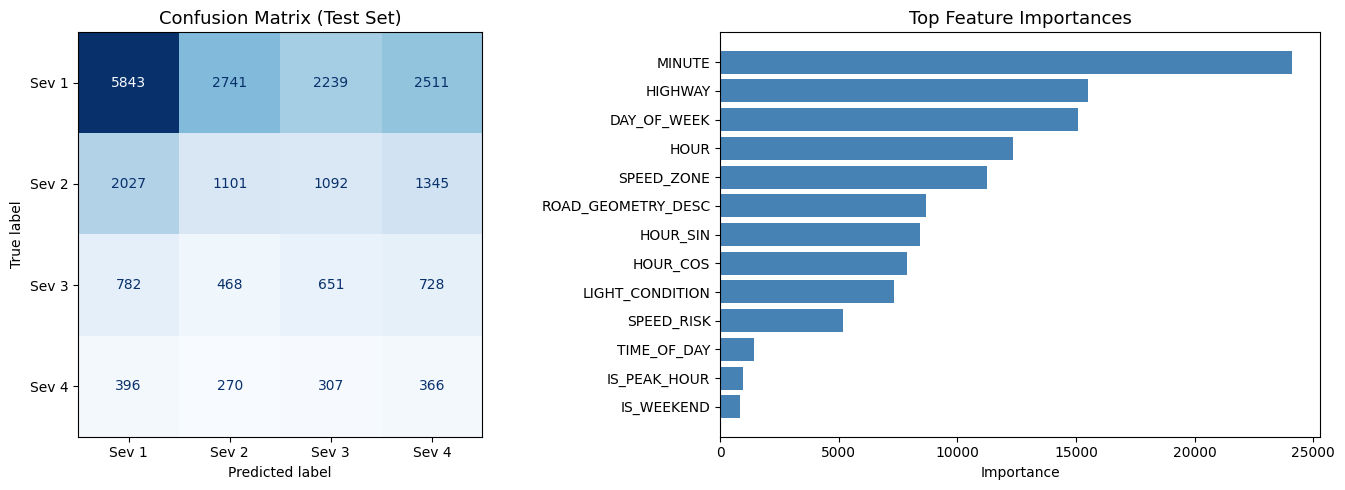

Plots saved ✓


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Sev 1','Sev 2','Sev 3','Sev 4']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Test Set)', fontsize=13)

# Feature importance
feat_names = (
    NUMERIC_FEATURES +
    CATEGORICAL_FEATURES
)
importance_df = pd.DataFrame({
    'feature': feat_names,
    'importance': lgbm_clf.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

axes[1].barh(importance_df['feature'], importance_df['importance'], color='steelblue')
axes[1].set_title('Top Feature Importances', fontsize=13)
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig(f'{ARTIFACT_DIR}/evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plots saved ✓')

## 9. Cross-Validation

In [13]:
# 5-fold stratified CV on full training data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Use full pipeline for CV (refit each fold)
full_pipeline_cv = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                              ('scl', StandardScaler())]), NUMERIC_FEATURES),
            ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                              ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))]),
             CATEGORICAL_FEATURES),
        ], remainder='drop')),
    ('classifier', LGBMClassifier(
        objective='multiclass', num_class=4,
        n_estimators=lgbm_clf.best_iteration_,  # use best found
        learning_rate=0.05, max_depth=7, num_leaves=63,
        class_weight=class_weight_dict,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    ))
])

cv_scores = cross_val_score(
    full_pipeline_cv, X, y,
    cv=cv, scoring='f1_macro', n_jobs=-1
)

print(f'CV Macro F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Fold scores: {np.round(cv_scores, 4)}')

CV Macro F1: 0.2627 ± 0.0033
Fold scores: [0.268  0.2649 0.2609 0.2607 0.259 ]


## 10. Save Artifacts

In [14]:
# Save preprocessor + model as separate artifacts
joblib.dump(preprocessor, f'{ARTIFACT_DIR}/preprocessor.joblib')
joblib.dump(lgbm_clf,     f'{ARTIFACT_DIR}/lgbm_model.joblib')

# Save feature metadata for Streamlit app
metadata = {
    'numeric_features': NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'all_features': ALL_FEATURES,
    'target_mapping': {
        '0': 'Severity 1 - Fatal',
        '1': 'Severity 2 - Serious Injury',
        '2': 'Severity 3 - Other Injury',
        '3': 'Severity 4 - Non-Injury'
    },
    'road_geometry_options': [
        'T intersection', 'Not at intersection', 'Cross intersection',
        'Multiple intersection', 'Unknown', 'Y intersection',
        'Dead end', 'Road closure', 'Private property'
    ],
    'highway_options': [
        'Mugling-Kurintar', 'Nagdhunga-Thankot', 'Dharke-Naubise',
        'Benighat-Malekhu', 'Kotre-Jamune', 'Naubise-Nagdhunga',
        'Galchhi-Dharke', 'Pokhara-Kotre', 'Thankot-Kalanki',
        'Jamune-Aabukhaireni', 'Other'
    ],
    'speed_zones': [30, 40, 50, 60, 70, 75, 80, 90, 100],
    'light_conditions': {
        '1': 'Day', '2': 'Dusk/Dawn', '3': 'Dark – street lights on',
        '4': 'Dark – no street lights', '5': 'Dark – street lights off',
        '6': 'Unknown', '9': 'Not applicable'
    },
    'model_metrics': {
        'accuracy': round(float(acc), 4),
        'macro_f1': round(float(f1_mac), 4),
        'weighted_f1': round(float(f1_w), 4),
        'cohen_kappa': round(float(kappa), 4)
    }
}

with open(f'{ARTIFACT_DIR}/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Artifacts saved:')
for fn in os.listdir(ARTIFACT_DIR):
    fsize = os.path.getsize(f'{ARTIFACT_DIR}/{fn}') / 1024
    print(f'  {fn:40s}  {fsize:.1f} KB')

Artifacts saved:
  evaluation_plots.png                      81.0 KB
  model_metadata.json                       1.7 KB
  preprocessor.joblib                       4.9 KB
  lgbm_model.joblib                         12999.9 KB


## 11. Quick Inference Test
Simulate a single real-time prediction call (what Streamlit will do).

In [15]:
def predict_severity(hour, minute, day_of_week, light_condition,
                     road_geometry, speed_zone, highway,
                     preprocessor, model):
    """
    Single-row real-time prediction.
    Returns (severity_class_1to4, probabilities_dict)
    """
    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)

    bins   = [-1, 5, 11, 16, 20, 23]
    labels = ['NIGHT','MORNING','AFTERNOON','EVENING','LATE_NIGHT']
    time_of_day = labels[pd.cut([hour], bins=bins, labels=False)[0]]

    speed_risk_map = {(0,50):'LOW',(50,70):'MEDIUM',(70,90):'HIGH',(90,999):'VERY_HIGH'}
    speed_risk = next(v for (lo,hi),v in speed_risk_map.items() if lo < speed_zone <= hi)

    is_peak   = int(hour in [7,8,9,17,18,19])
    is_weekend = int(day_of_week in [6,7])

    row = pd.DataFrame([{
        'HOUR': hour, 'MINUTE': minute,
        'HOUR_SIN': hour_sin, 'HOUR_COS': hour_cos,
        'DAY_OF_WEEK': day_of_week, 'LIGHT_CONDITION': light_condition,
        'SPEED_ZONE': speed_zone, 'IS_PEAK_HOUR': is_peak, 'IS_WEEKEND': is_weekend,
        'ROAD_GEOMETRY_DESC': road_geometry, 'HIGHWAY': highway,
        'TIME_OF_DAY': time_of_day, 'SPEED_RISK': speed_risk
    }])

    X_proc = preprocessor.transform(row)
    pred   = model.predict(X_proc)[0]
    proba  = model.predict_proba(X_proc)[0]

    return int(pred) + 1, {f'Severity {i+1}': round(float(p)*100, 2) for i,p in enumerate(proba)}


# Test it
severity, probs = predict_severity(
    hour=8, minute=30, day_of_week=1, light_condition=1,
    road_geometry='T intersection', speed_zone=60,
    highway='Mugling-Kurintar',
    preprocessor=preprocessor, model=lgbm_clf
)
print(f'Predicted Severity : {severity}')
print(f'Probabilities      : {probs}')

Predicted Severity : 4
Probabilities      : {'Severity 1': 11.13, 'Severity 2': 21.9, 'Severity 3': 30.98, 'Severity 4': 35.99}


In [16]:
import os
print(os.path.abspath(ARTIFACT_DIR))

/Users/adeshbohara/Desktop/artifacts
